In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)


In [22]:
df1 = pd.read_csv('../data/diabetes_dataset.csv')
df1 = df1.drop(df1.columns[0], axis=1)
print("Shape:", df1.shape)
df1.head()


Shape: (10000, 20)


,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,58,Female,White,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,183.4,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,203.2,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0


In [23]:

df1 = df1.drop(["Cholesterol_HDL","Cholesterol_LDL","GGT","Serum_Urate","Blood_Pressure_Systolic",
                "Blood_Pressure_Diastolic","Cholesterol_Total","Previous_Gestational_Diabetes"], axis=1)
df1.info()
df1.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         10000 non-null  int64  
 1   Sex                         10000 non-null  object 
 2   Ethnicity                   10000 non-null  object 
 3   BMI                         10000 non-null  float64
 4   Waist_Circumference         10000 non-null  float64
 5   Fasting_Blood_Glucose       10000 non-null  float64
 6   HbA1c                       10000 non-null  float64
 7   Physical_Activity_Level     10000 non-null  object 
 8   Dietary_Intake_Calories     10000 non-null  int64  
 9   Alcohol_Consumption         6680 non-null   object 
 10  Smoking_Status              10000 non-null  object 
 11  Family_History_of_Diabetes  10000 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 937.6+ KB


,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes
count,10000.000000,10000,10000,10000.000000,10000.00000,10000.000000,10000.000000,10000,10000.000000,6680,10000,10000.000000
unique,NaN,2,4,NaN,NaN,NaN,NaN,3,NaN,2,3,NaN
top,NaN,Female,Black,NaN,NaN,NaN,NaN,Low,NaN,Moderate,Current,NaN
freq,NaN,5005,2539,NaN,NaN,NaN,NaN,3372,NaN,3373,3364,NaN
mean,44.620400,NaN,NaN,29.418150,94.79707,134.776210,9.507510,NaN,2742.481900,NaN,NaN,0.507000
std,14.343489,NaN,NaN,6.170866,14.38329,37.633544,3.176421,NaN,716.643803,NaN,NaN,0.499976
min,20.000000,NaN,NaN,18.500000,70.00000,70.000000,4.000000,NaN,1500.000000,NaN,NaN,0.000000
25%,32.000000,NaN,NaN,24.100000,82.20000,102.175000,6.800000,NaN,2129.000000,NaN,NaN,0.000000
50%,45.000000,NaN,NaN,29.500000,94.90000,134.500000,9.500000,NaN,2727.000000,NaN,NaN,1.000000
75%,57.000000,NaN,NaN,34.700000,107.00000,167.800000,12.300000,NaN,3368.000000,NaN,NaN,1.000000


Missing values per column:
Age                              0
Sex                              0
Ethnicity                        0
BMI                              0
Waist_Circumference              0
Fasting_Blood_Glucose            0
HbA1c                            0
Physical_Activity_Level          0
Dietary_Intake_Calories          0
Alcohol_Consumption           3320
Smoking_Status                   0
Family_History_of_Diabetes       0
dtype: int64


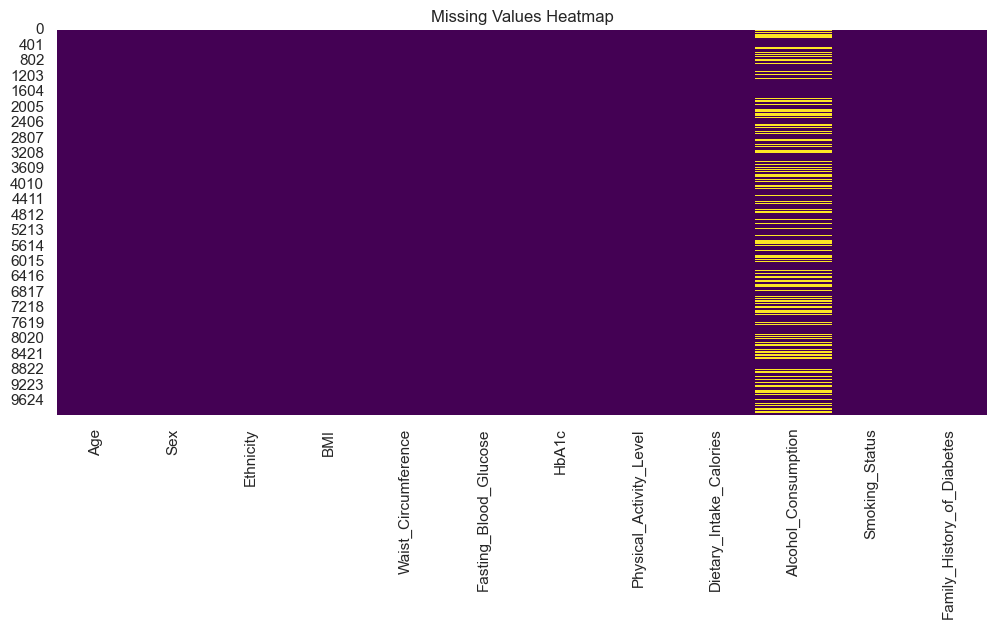

In [24]:
# Missing values count
print("Missing values per column:")
print(df1.isnull().sum())

# Heatmap
plt.figure(figsize=(12,5))
sns.heatmap(df1.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


Missing values per column:
Age                           0
Sex                           0
Ethnicity                     0
BMI                           0
Waist_Circumference           0
Fasting_Blood_Glucose         0
HbA1c                         0
Physical_Activity_Level       0
Dietary_Intake_Calories       0
Alcohol_Consumption           0
Smoking_Status                0
Family_History_of_Diabetes    0
dtype: int64


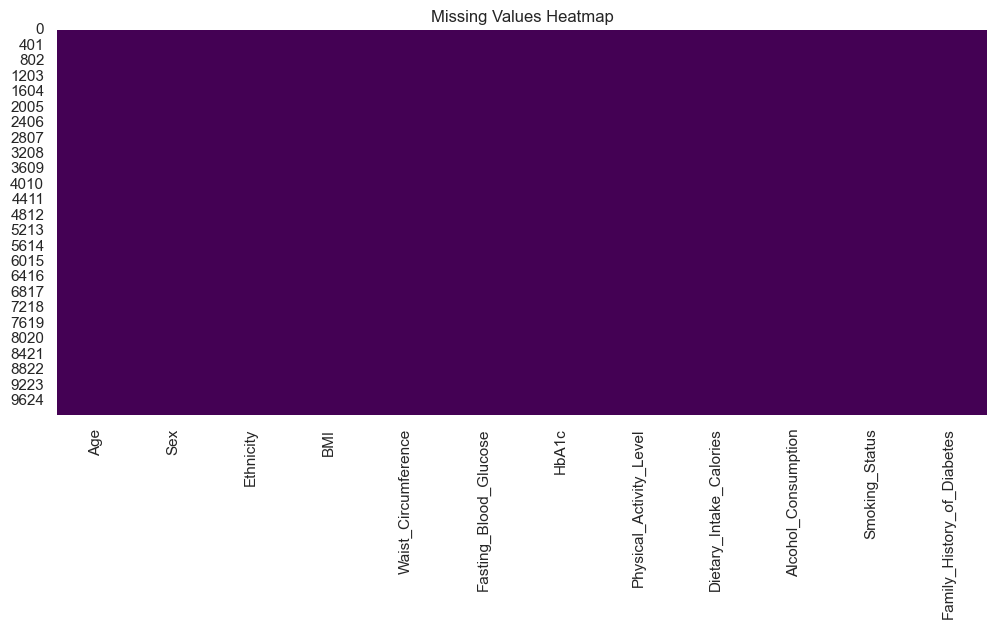

In [25]:
 # Handling Missing Values: Alcohol_Consumption
df1["Alcohol_Consumption"] = df1["Alcohol_Consumption"].fillna("None")

# Missing values count
print("Missing values per column:")
print(df1.isnull().sum())

# Heatmap
plt.figure(figsize=(12,5))
sns.heatmap(df1.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [26]:
df1.head()

,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes
0,58,Female,White,35.8,83.4,123.9,10.9,Moderate,1538,Moderate,Never,0
1,48,Male,Asian,24.1,71.4,183.7,12.8,Moderate,2653,Moderate,Current,0
2,34,Female,Black,25.0,113.8,142.0,14.5,Low,1684,Heavy,Former,1
3,62,Male,Asian,32.7,100.4,167.4,8.8,Low,3796,Moderate,Never,1
4,27,Female,Asian,33.5,110.8,146.4,7.1,Moderate,3161,Heavy,Current,0


In [27]:
# Identifying duplications
duplications = df1.duplicated().sum()
print("Number of duplicates:", duplications)

Number of duplicates: 0


In [28]:
df_encoded = df1.copy()

# Label Encoding for Binary Categorical
binary_cat = ['Sex']   # Add more binary cols if needed

for col in binary_cat:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding for remaining multi-category columns
all_cat_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
multi_cat = [c for c in all_cat_cols if c not in binary_cat]

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_encoded[multi_cat])

one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(multi_cat),
    index=df_encoded.index
).astype('int64')   # Convert float64 -> int64

# Final encoded dataset
df_encoded = pd.concat([df_encoded.drop(columns=multi_cat), one_hot_df], axis=1)

df_encoded.head()


,Age,Sex,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Dietary_Intake_Calories,Family_History_of_Diabetes,Ethnicity_Asian,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_High,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Heavy,Alcohol_Consumption_Moderate,Alcohol_Consumption_None,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never
0,58,0,35.8,83.4,123.9,10.9,1538,0,0,0,0,1,0,0,1,0,1,0,0,0,1
1,48,1,24.1,71.4,183.7,12.8,2653,0,1,0,0,0,0,0,1,0,1,0,1,0,0
2,34,0,25.0,113.8,142.0,14.5,1684,1,0,1,0,0,0,1,0,1,0,0,0,1,0
3,62,1,32.7,100.4,167.4,8.8,3796,1,1,0,0,0,0,1,0,0,1,0,0,0,1
4,27,0,33.5,110.8,146.4,7.1,3161,0,1,0,0,0,0,0,1,1,0,0,1,0,0


In [29]:
df_scaled = df_encoded.copy()

columns_to_scale = ['Age', 'BMI', 'Waist_Circumference', 'Fasting_Blood_Glucose', 'HbA1c', 'Dietary_Intake_Calories']

scaler = StandardScaler()
df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])

df_scaled[columns_to_scale].head()


,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Dietary_Intake_Calories
0,0.932846,1.034242,-0.792422,-0.289018,0.438405,-1.680810
1,0.235631,-0.861859,-1.626765,1.300070,1.036593,-0.124869
2,-0.740471,-0.716005,1.321247,0.191960,1.571813,-1.477072
3,1.211732,0.531856,0.389564,0.866924,-0.222749,1.470146
4,-1.228521,0.661504,1.112661,0.308883,-0.757970,0.584027


In [30]:
df_outlier = df_scaled.copy()

columns_to_check = columns_to_scale  # same features

outlier_summary = []

for col in columns_to_check:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    before = df_outlier.shape[0]
    df_outlier = df_outlier[(df_outlier[col] >= lower) & (df_outlier[col] <= upper)]
    after = df_outlier.shape[0]
    
    outlier_summary.append({
        "Feature": col,
        "Outliers Removed": before - after,
        "Remaining Rows": after
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df


,Feature,Outliers Removed,Remaining Rows
0,Age,0,10000
1,BMI,0,10000
2,Waist_Circumference,0,10000
3,Fasting_Blood_Glucose,0,10000
4,HbA1c,0,10000
5,Dietary_Intake_Calories,0,10000


In [31]:
# Save the final cleaned dataset for 02_feature_analysis.ipynb
df_outlier.to_csv('../data/diabetes_cleaned.csv', index=False)
print("✅ Saved: ../data/diabetes_cleaned.csv")


✅ Saved: ../data/diabetes_cleaned.csv
